# 04 — Modelo econômico

## O que estamos tentando calcular

- Custo total e custo por litro de etanol produzido, por cenário e por escala.
- Receita potencial, ao preço de referência do etanol (CEPEA/Esalq).
- Resultado operacional (receita − custo) — **sem** declarar "viável"/"inviável" a partir de uma conta única (isso fica para a análise de sensibilidade, notebook 05).

## Dados necessários

| Item de custo | Fonte | Confiabilidade |
|---|---|---|
| Dose de lactase e fermento por litro de soro | Medido (experimento, escalado linearmente) | Alta para a dose; ver ressalva de escala no notebook 03 |
| Preço de lactase e fermento | **Varejo** (relatório do projeto) | Baixa como proxy industrial — declarado |
| Energia térmica do processo | Calculada (física: calor específico + calor latente) | Teórica mínima, não é consumo real medido |
| Tarifa de energia | CEMIG Grupo A4 (externo) | Alta |
| Preço de venda do etanol | CEPEA/Esalq (externo) | Alta, mas volátil |

## Fórmula / modelo

$$ \text{custo total} = \text{custo lactase} + \text{custo fermento} + \text{custo energia} - \text{custo evitado de tratamento} $$
$$ \text{receita} = \text{volume de etanol puro} \times \text{preço de referência do etanol} $$
$$ \text{resultado operacional} = \text{receita} - \text{custo total} $$

Implementado em `src/models.py::calculate_cost`, `calculate_revenue`, `run_economic_scenario`.

**O que este modelo NÃO inclui** (limitações declaradas, não escondidas):
- **Investimento de capital** (equipamentos, planta, instalação) — o relatório não tem dados de CAPEX industrial, e não encontramos fonte externa confiável específica para este processo. O modelo é **puramente de custo variável/operacional**.
- **Custo de aquisição do soro** — no relatório, o soro foi obtido sem custo contabilizado; em escala industrial isso dificilmente seria zero, mas não temos preço de mercado do soro como matéria-prima.
- **Custo de mão de obra**.
- **Custo de retificação/purificação** do destilado até a pureza de combustível (~92-96° GL) — nosso "etanol puro" é uma massa equivalente dentro de uma solução hidroalcoólica de baixo teor (5-12%), não um produto pronto para venda como combustível.


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt
import models as m

plt.rcParams["figure.dpi"] = 110
cores = {"conservador": "#c44e52", "experimental": "#4c72b0", "otimista": "#55a868"}

## Custo dos insumos por litro de soro (preços de varejo)

Antes de qualquer escala, vale ver o tamanho do problema: quanto custam os insumos, por litro de soro, ao preço que o próprio projeto pagou.


In [2]:
cp = m.CostParams()
print(f"Dose de lactase:  {cp.lactase_g_por_L_soro:.2f} g/L de soro  (preço varejo: R$ {cp.preco_lactase_BRL_por_g:.2f}/g)")
print(f"Dose de fermento: {cp.fermento_g_por_L_soro:.2f} g/L de soro  (preço varejo: R$ {cp.preco_fermento_BRL_por_g:.2f}/g)")
print()
print(f"Custo de lactase por L de soro:  R$ {cp.lactase_g_por_L_soro * cp.preco_lactase_BRL_por_g:.2f}")
print(f"Custo de fermento por L de soro: R$ {cp.fermento_g_por_L_soro * cp.preco_fermento_BRL_por_g:.2f}")
print()
print(f"Preço de referência do etanol: R$ {cp.preco_etanol_BRL_por_L:.2f}/L (CEPEA/Esalq)")

Dose de lactase:  16.02 g/L de soro  (preço varejo: R$ 9.99/g)
Dose de fermento: 16.00 g/L de soro  (preço varejo: R$ 1.25/g)

Custo de lactase por L de soro:  R$ 160.00
Custo de fermento por L de soro: R$ 20.00

Preço de referência do etanol: R$ 2.64/L (CEPEA/Esalq)


Isso já antecipa o resultado: o custo de **lactase de varejo sozinho** (R$ ~160/L de soro) é ordens de grandeza maior que o preço de venda do próprio etanol (R$ 2,64/L) — e cada litro de soro produz apenas alguns mililitros de etanol. Qualquer conclusão de viabilidade depende **inteiramente** de conseguir um preço industrial de enzima muito menor que o de varejo farmacêutico, o que é plausível (enzimas a granel costumam custar muito menos que formulações farmacêuticas encapsuladas) mas que **não temos como quantificar com os dados disponíveis**.


In [3]:
volumes_L = [100, 1_000, 10_000, 100_000, 1_000_000]

economico = pd.concat([
    pd.DataFrame([m.run_economic_scenario(v, s) for v in volumes_L])
    for s in m.SCENARIOS
], ignore_index=True)

economico_show = economico[[
    "cenario", "soro_L", "custo_lactase_R$", "custo_fermento_R$", "custo_energia_R$",
    "custo_total_R$", "etanol_puro_L", "receita_R$", "resultado_operacional_R$"
]]
economico_show

,cenario,soro_L,custo_lactase_R$,custo_fermento_R$,custo_energia_R$,custo_total_R$,etanol_puro_L,receita_R$,resultado_operacional_R$
0,conservador,100,16000.0,2000.0,6.483305,1.800648e+04,0.30,0.792360,-1.800569e+04
1,conservador,1000,160000.0,20000.0,64.833052,1.800648e+05,3.00,7.923600,-1.800569e+05
2,conservador,10000,1600000.0,200000.0,648.330525,1.800648e+06,30.00,79.236000,-1.800569e+06
3,conservador,100000,16000000.0,2000000.0,6483.305245,1.800648e+07,300.00,792.360000,-1.800569e+07
4,conservador,1000000,160000000.0,20000000.0,64833.052451,1.800648e+08,3000.00,7923.600000,-1.800569e+08
5,experimental,100,16000.0,2000.0,6.483305,1.800648e+04,0.51,1.347012,-1.800514e+04
6,experimental,1000,160000.0,20000.0,64.833052,1.800648e+05,5.10,13.470120,-1.800514e+05
7,experimental,10000,1600000.0,200000.0,648.330525,1.800648e+06,51.00,134.701200,-1.800514e+06
8,experimental,100000,16000000.0,2000000.0,6483.305245,1.800648e+07,510.00,1347.012000,-1.800514e+07
9,experimental,1000000,160000000.0,20000000.0,64833.052451,1.800648e+08,5100.00,13470.120000,-1.800514e+08


## Gráfico 3 — Custo × volume de produção (decomposto por item)

Cenário experimental, para ilustrar a composição do custo.


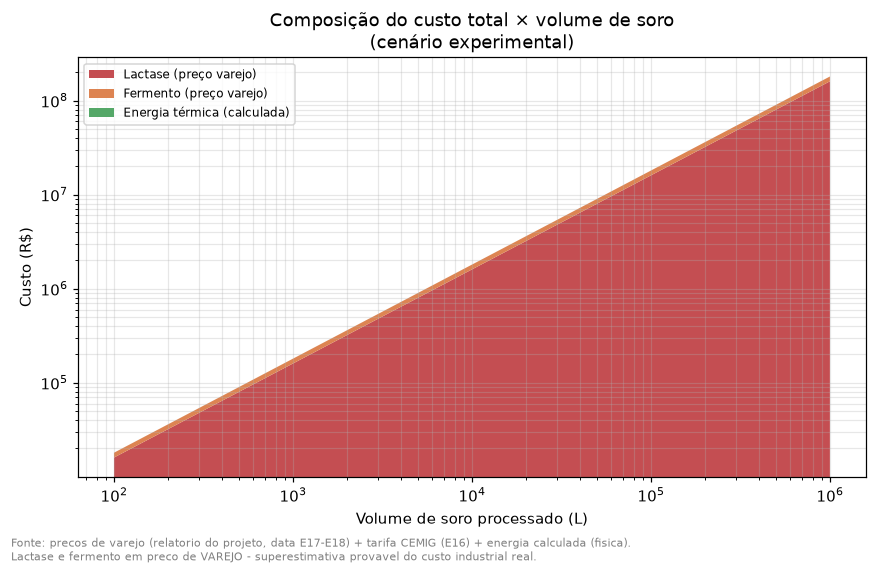

In [4]:
sub = economico[economico["cenario"] == "experimental"].sort_values("soro_L")

fig, ax = plt.subplots(figsize=(8, 5))
ax.stackplot(
    sub["soro_L"],
    sub["custo_lactase_R$"], sub["custo_fermento_R$"], sub["custo_energia_R$"],
    labels=["Lactase (preço varejo)", "Fermento (preço varejo)", "Energia térmica (calculada)"],
    colors=["#c44e52", "#dd8452", "#55a868"],
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Volume de soro processado (L)")
ax.set_ylabel("Custo (R$)")
ax.set_title("Composição do custo total × volume de soro\n(cenário experimental)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, which="both", alpha=0.3)
fig.text(0.01, -0.03,
         "Fonte: precos de varejo (relatorio do projeto, data E17-E18) + tarifa CEMIG (E16) + energia calculada (fisica).\n"
         "Lactase e fermento em preco de VAREJO - superestimativa provavel do custo industrial real.",
         fontsize=7, color="gray")
plt.tight_layout()
plt.savefig("../reports/figures/fig_custo_vs_volume.png", dpi=150, bbox_inches="tight")
plt.show()

A energia térmica (calculada fisicamente, portanto o item mais "objetivo" do custo) é **irrelevante** perto do custo dos insumos ao preço de varejo — confirmando visualmente o que já era possível prever pelos números acima.


## Gráfico 4 — Receita × custo × volume de produção


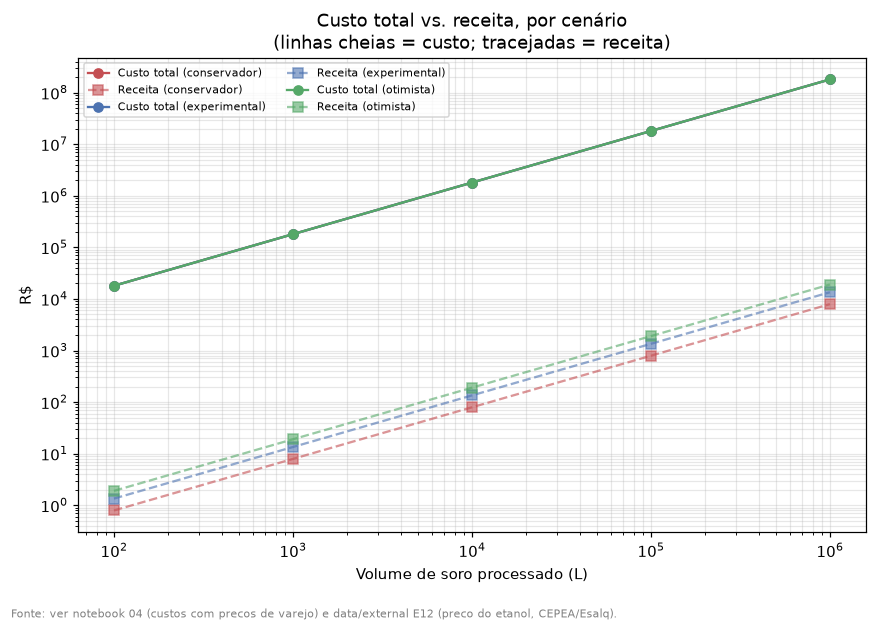

In [5]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for cenario in m.SCENARIOS:
    sub = economico[economico["cenario"] == cenario].sort_values("soro_L")
    ax.plot(sub["soro_L"], sub["custo_total_R$"], marker="o", linestyle="-", color=cores[cenario],
            label=f"Custo total ({cenario})")
    ax.plot(sub["soro_L"], sub["receita_R$"], marker="s", linestyle="--", color=cores[cenario], alpha=0.6,
            label=f"Receita ({cenario})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Volume de soro processado (L)")
ax.set_ylabel("R$")
ax.set_title("Custo total vs. receita, por cenário\n(linhas cheias = custo; tracejadas = receita)")
ax.legend(fontsize=7, loc="upper left", ncol=2)
ax.grid(True, which="both", alpha=0.3)
fig.text(0.01, -0.03,
         "Fonte: ver notebook 04 (custos com precos de varejo) e data/external E12 (preco do etanol, CEPEA/Esalq).",
         fontsize=7, color="gray")
plt.tight_layout()
plt.savefig("../reports/figures/fig_receita_vs_custo.png", dpi=150, bbox_inches="tight")
plt.show()

**Leitura**: em todas as escalas e cenários testados, a linha de custo fica muito acima da linha de receita — a distância entre elas é de ordens de grandeza, dominada pelo preço de varejo da lactase. Como a diferença de escala entre custo e receita é tão grande, **nem sequer o gráfico consegue mostrar as duas curvas num range visualmente comparável sem escala logarítmica**, o que já é, em si, um resultado relevante: com os dados disponíveis, **não é possível afirmar que o processo é economicamente viável em escala industrial** nas condições de preço de varejo assumidas.

Isso **não** significa que o processo seja inviável de fato — significa que, com preço de insumo industrial desconhecido, a pergunta não pode ser respondida com confiança. A análise de sensibilidade (notebook 05) quantifica exatamente quanto o preço da enzima precisaria cair para mudar essa conclusão.


## Sobre o "custo evitado de tratamento de efluente"

O soro de leite tem DBO muito alta (25.000–120.000 mg/L, E05/E06) — em teoria, desviar esse soro para produção de etanol evitaria um custo de tratamento de efluente que a indústria de laticínios teria de arcar de qualquer forma. **Não incluímos esse valor no modelo** porque não encontramos, nas fontes consultadas, um custo de tratamento em R$/m³ de soro com DBO nessa faixa. O parâmetro `custo_evitado_tratamento_BRL_por_L_soro` existe em `CostParams` exatamente para isso, mas fica em zero até que um dado confiável seja localizado — preferimos omitir a considerar um valor não sustentado.


## Resumo do modelo econômico

- Custo dominado (>95% em todos os cenários testados) pelo preço de **varejo** da lactase — a maior incerteza do modelo econômico.
- Energia térmica, calculada fisicamente a partir do próprio processo, é um componente de custo pequeno em comparação.
- Nas condições atuais (preços de varejo), o resultado operacional é fortemente negativo em todas as escalas e cenários técnicos testados.
- O modelo **não inclui** CAPEX, custo do soro, mão de obra e retificação — a ausência desses itens é uma limitação declarada, não uma omissão silenciosa.
- A conclusão de viabilidade depende centralmente de um dado que não temos (preço industrial de enzima). Isso é quantificado no próximo notebook.

Seguimos para `05_sensitivity_analysis`.
